# CS201L: Artificial Intelligence Laboratory
## Practice Set: Distance-Based Classification using K-Nearest Neighbors (KNN)

 
**Date:** 01-02-2026

---
## Import Required Libraries

In [1]:
# Import all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Settings
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
np.random.seed(42)

print("All libraries imported successfully!")

All libraries imported successfully!


---
# Part A: Data Preparation and Splitting

## Step 1: Load the Dataset

In [2]:
# Load the dataset
df = pd.read_csv('Date_Fruit_Datasets.csv')

# Display shape
print("Dataset Shape:", df.shape)

# Display first 5 rows
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (898, 35)

First 5 rows:


,AREA,PERIMETER,MAJOR_AXIS,MINOR_AXIS,ECCENTRICITY,EQDIASQ,SOLIDITY,CONVEX_AREA,EXTENT,ASPECT_RATIO,...,KurtosisRR,KurtosisRG,KurtosisRB,EntropyRR,EntropyRG,EntropyRB,ALLdaub4RR,ALLdaub4RG,ALLdaub4RB,Class
0,422163,2378.908,837.8484,645.6693,0.6373,733.1539,0.9947,424428,0.7831,1.2976,...,3.2370,2.9574,4.2287,-59191263232,-50714214400,-39922372608,58.7255,54.9554,47.8400,BERHI
1,338136,2085.144,723.8198,595.2073,0.5690,656.1464,0.9974,339014,0.7795,1.2161,...,2.6228,2.6350,3.1704,-34233065472,-37462601728,-31477794816,50.0259,52.8168,47.8315,BERHI
2,526843,2647.394,940.7379,715.3638,0.6494,819.0222,0.9962,528876,0.7657,1.3150,...,3.7516,3.8611,4.7192,-93948354560,-74738221056,-60311207936,65.4772,59.2860,51.9378,BERHI
3,416063,2351.210,827.9804,645.2988,0.6266,727.8378,0.9948,418255,0.7759,1.2831,...,5.0401,8.6136,8.2618,-32074307584,-32060925952,-29575010304,43.3900,44.1259,41.1882,BERHI
4,347562,2160.354,763.9877,582.8359,0.6465,665.2291,0.9908,350797,0.7569,1.3108,...,2.7016,2.9761,4.4146,-39980974080,-35980042240,-25593278464,52.7743,50.9080,42.6666,BERHI


## Step 2: Basic Dataset Information

In [3]:
# Dataset info
print("Dataset Info:")
print(df.info())

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum().sum())

# Display class distribution
print("\nClass Distribution:")
print(df['Class'].value_counts())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 898 entries, 0 to 897
Data columns (total 35 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   AREA           898 non-null    int64  
 1   PERIMETER      898 non-null    float64
 2   MAJOR_AXIS     898 non-null    float64
 3   MINOR_AXIS     898 non-null    float64
 4   ECCENTRICITY   898 non-null    float64
 5   EQDIASQ        898 non-null    float64
 6   SOLIDITY       898 non-null    float64
 7   CONVEX_AREA    898 non-null    int64  
 8   EXTENT         898 non-null    float64
 9   ASPECT_RATIO   898 non-null    float64
 10  ROUNDNESS      898 non-null    float64
 11  COMPACTNESS    898 non-null    float64
 12  SHAPEFACTOR_1  898 non-null    float64
 13  SHAPEFACTOR_2  898 non-null    float64
 14  SHAPEFACTOR_3  898 non-null    float64
 15  SHAPEFACTOR_4  898 non-null    float64
 16  MeanRR         898 non-null    float64
 17  MeanRG         898 non-null    float64
 

## Step 3: Separate Features (X) and Target (y)

In [4]:
# Separate features and target
X = df.drop('Class', axis=1)
y = df['Class']

print("Features (X) shape:", X.shape)
print("Target  (y) shape:", y.shape)

print("\nFeature columns:")
print(X.columns.tolist())

Features (X) shape: (898, 34)
Target  (y) shape: (898,)

Feature columns:
['AREA', 'PERIMETER', 'MAJOR_AXIS', 'MINOR_AXIS', 'ECCENTRICITY', 'EQDIASQ', 'SOLIDITY', 'CONVEX_AREA', 'EXTENT', 'ASPECT_RATIO', 'ROUNDNESS', 'COMPACTNESS', 'SHAPEFACTOR_1', 'SHAPEFACTOR_2', 'SHAPEFACTOR_3', 'SHAPEFACTOR_4', 'MeanRR', 'MeanRG', 'MeanRB', 'StdDevRR', 'StdDevRG', 'StdDevRB', 'SkewRR', 'SkewRG', 'SkewRB', 'KurtosisRR', 'KurtosisRG', 'KurtosisRB', 'EntropyRR', 'EntropyRG', 'EntropyRB', 'ALLdaub4RR', 'ALLdaub4RG', 'ALLdaub4RB']


## Step 4: Train – Validation – Test Split (60% – 20% – 20%)

In [5]:
# --------------------------------------------------------------------------
# First split  →  60% Train  |  40% Temp (Validation + Test)
# --------------------------------------------------------------------------
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.4,
    stratify=y,
    random_state=42
)

# --------------------------------------------------------------------------
# Second split  →  Temp split equally into 20% Validation | 20% Test
# --------------------------------------------------------------------------
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42
)

# Print sizes
print("Split Summary:")
print(f"  Training set  : {X_train.shape[0]} samples  ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"  Validation set: {X_val.shape[0]} samples   ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"  Test set      : {X_test.shape[0]} samples   ({X_test.shape[0]/len(X)*100:.1f}%)")

# Verify stratification – class-wise counts
print("\nClass distribution per split:")
print(f"  Train :  {y_train.value_counts().sort_index().tolist()}")
print(f"  Val   :  {y_val.value_counts().sort_index().tolist()}")
print(f"  Test  :  {y_test.value_counts().sort_index().tolist()}")

Split Summary:
  Training set  : 538 samples  (59.9%)
  Validation set: 180 samples   (20.0%)
  Test set      : 180 samples   (20.0%)

Class distribution per split:
  Train :  [39, 59, 122, 43, 100, 119, 56]
  Val   :  [13, 19, 41, 15, 33, 40, 19]
  Test  :  [13, 20, 41, 14, 33, 40, 19]


## Step 5: Save Splits as CSV Files

In [6]:
# Re-attach the Class label before saving
train_df = pd.concat([X_train, y_train], axis=1)
val_df  = pd.concat([X_val,   y_val],   axis=1)
test_df = pd.concat([X_test,  y_test],  axis=1)

# Save to CSV
train_df.to_csv('DateFruit_Train.csv',       index=False)
val_df.to_csv('DateFruit_Validation.csv',    index=False)
test_df.to_csv('DateFruit_Test.csv',         index=False)

print("CSV files saved successfully:")
print(f"  ✓ DateFruit_Train.csv        – {train_df.shape}")
print(f"  ✓ DateFruit_Validation.csv   – {val_df.shape}")
print(f"  ✓ DateFruit_Test.csv         – {test_df.shape}")

CSV files saved successfully:
  ✓ DateFruit_Train.csv        – (538, 35)
  ✓ DateFruit_Validation.csv   – (180, 35)
  ✓ DateFruit_Test.csv         – (180, 35)


---
# Part B: KNN Model Selection using Validation Data

## Step 1: Load the Saved CSV Files

In [7]:
# Load saved CSV files
train_data = pd.read_csv('DateFruit_Train.csv')
val_data   = pd.read_csv('DateFruit_Validation.csv')
test_data  = pd.read_csv('DateFruit_Test.csv')

# ---------- Training ----------
X_train = train_data.drop('Class', axis=1)
y_train = train_data['Class']

# ---------- Validation ----------
X_val = val_data.drop('Class', axis=1)
y_val = val_data['Class']

# ---------- Test ----------
X_test = test_data.drop('Class', axis=1)
y_test = test_data['Class']

print("Data loaded from CSV files:")
print(f"  Train : {X_train.shape}")
print(f"  Val   : {X_val.shape}")
print(f"  Test  : {X_test.shape}")

Data loaded from CSV files:
  Train : (538, 34)
  Val   : (180, 34)
  Test  : (180, 34)


## Step 2: Define K Values and Run KNN on Validation Data

In [8]:
# K values to evaluate
k_values = [1, 3, 7, 11]

# List to store results for every K
validation_results = []

print("KNN – Validation Results")
print("=" * 80)

for k in k_values:
    # ----- Train -----
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

    # ----- Predict on Validation -----
    y_val_pred = knn.predict(X_val)

    # ----- Compute all metrics -----
    acc            = accuracy_score(y_val, y_val_pred)
    prec_micro     = precision_score(y_val, y_val_pred, average='micro')
    prec_macro     = precision_score(y_val, y_val_pred, average='macro')
    rec_micro      = recall_score(y_val, y_val_pred,    average='micro')
    rec_macro      = recall_score(y_val, y_val_pred,    average='macro')
    f1_micro       = f1_score(y_val, y_val_pred,        average='micro')
    f1_macro       = f1_score(y_val, y_val_pred,        average='macro')

    # Store in list
    validation_results.append({
        'K'              : k,
        'Accuracy'       : acc,
        'Precision_Micro': prec_micro,
        'Precision_Macro': prec_macro,
        'Recall_Micro'   : rec_micro,
        'Recall_Macro'   : rec_macro,
        'F1_Micro'       : f1_micro,
        'F1_Macro'       : f1_macro
    })

    print(f"  K = {k:2d}  |  Accuracy: {acc:.4f}  |  "
          f"Prec(M): {prec_macro:.4f}  |  "
          f"Rec(M): {rec_macro:.4f}  |  "
          f"F1(M): {f1_macro:.4f}")

print("=" * 80)

KNN – Validation Results
  K =  1  |  Accuracy: 0.6333  |  Prec(M): 0.5303  |  Rec(M): 0.5281  |  F1(M): 0.5225
  K =  3  |  Accuracy: 0.6222  |  Prec(M): 0.5450  |  Rec(M): 0.5177  |  F1(M): 0.5292
  K =  7  |  Accuracy: 0.6889  |  Prec(M): 0.5719  |  Rec(M): 0.5646  |  F1(M): 0.5622
  K = 11  |  Accuracy: 0.7000  |  Prec(M): 0.5965  |  Rec(M): 0.5812  |  F1(M): 0.5801


## Step 3: Display Full Validation Metrics Table

In [9]:
# Convert results list to a DataFrame
val_results_df = pd.DataFrame(validation_results)

# Round values for clean display
display_df = val_results_df.copy()
display_df.iloc[:, 1:] = display_df.iloc[:, 1:].round(4)

print("Complete Validation Metrics for All K Values:")
print()
print(display_df.to_string(index=False))

Complete Validation Metrics for All K Values:

 K  Accuracy  Precision_Micro  Precision_Macro  Recall_Micro  Recall_Macro  F1_Micro  F1_Macro
 1    0.6333           0.6333           0.5303        0.6333        0.5281    0.6333    0.5225
 3    0.6222           0.6222           0.5450        0.6222        0.5177    0.6222    0.5292
 7    0.6889           0.6889           0.5719        0.6889        0.5646    0.6889    0.5622
11    0.7000           0.7000           0.5965        0.7000        0.5812    0.7000    0.5801


## Step 4: Plot Accuracy vs. K (Validation)

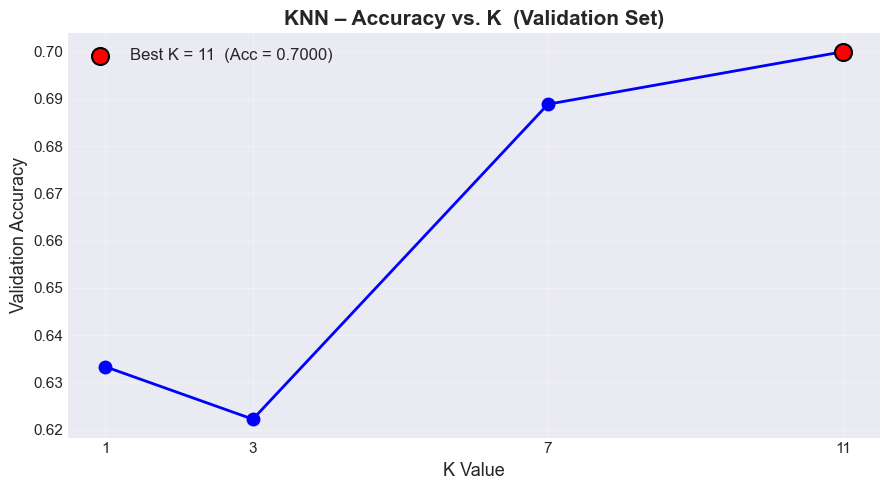

Best K selected from validation: 11  (Accuracy = 0.7000)


In [10]:
# Identify the best K
best_idx       = val_results_df['Accuracy'].idxmax()
best_k         = int(val_results_df.loc[best_idx, 'K'])
best_val_acc   = val_results_df.loc[best_idx, 'Accuracy']

# ---------- Plot ----------
plt.figure(figsize=(9, 5))

plt.plot(val_results_df['K'], val_results_df['Accuracy'],
         'bo-', linewidth=2, markersize=9, zorder=3)

# Highlight best K
plt.scatter([best_k], [best_val_acc],
            color='red', s=150, edgecolors='black',
            linewidths=1.5, zorder=4,
            label=f'Best K = {best_k}  (Acc = {best_val_acc:.4f})')

plt.xlabel('K Value', fontsize=13)
plt.ylabel('Validation Accuracy', fontsize=13)
plt.title('KNN – Accuracy vs. K  (Validation Set)', fontsize=15, fontweight='bold')
plt.xticks(k_values, fontsize=11)
plt.yticks(fontsize=11)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('accuracy_vs_k.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Best K selected from validation: {best_k}  (Accuracy = {best_val_acc:.4f})")

---
# Part C: Final Evaluation on Test Data

## Step 1: Using Best K and Predict on Test Set

In [17]:
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train, y_train)

# Predict on the test set  (used ONLY here)
y_test_pred = knn_final.predict(X_test)

print(f"Predictions generated for {len(y_test_pred)} test samples using best K")

Predictions generated for 180 test samples using best K


## Step 2: Compute and Print All Test Metrics

In [12]:
# ---------- Compute every required metric ----------
test_acc        = accuracy_score(y_test, y_test_pred)
test_prec_micro = precision_score(y_test, y_test_pred, average='micro')
test_prec_macro = precision_score(y_test, y_test_pred, average='macro')
test_rec_micro  = recall_score(y_test, y_test_pred,    average='micro')
test_rec_macro  = recall_score(y_test, y_test_pred,    average='macro')
test_f1_micro   = f1_score(y_test, y_test_pred,        average='micro')
test_f1_macro   = f1_score(y_test, y_test_pred,        average='macro')

# ---------- Print ----------
print("=" * 50)
print("  TEST SET RESULTS")
print(f"  Best K  =  {best_k}")
print("=" * 50)
print(f"  Accuracy          :  {test_acc:.4f}")
print("-" * 50)
print(f"  Precision (Micro) :  {test_prec_micro:.4f}")
print(f"  Precision (Macro) :  {test_prec_macro:.4f}")
print("-" * 50)
print(f"  Recall    (Micro) :  {test_rec_micro:.4f}")
print(f"  Recall    (Macro) :  {test_rec_macro:.4f}")
print("-" * 50)
print(f"  F1-Score  (Micro) :  {test_f1_micro:.4f}")
print(f"  F1-Score  (Macro) :  {test_f1_macro:.4f}")
print("=" * 50)

  TEST SET RESULTS
  Best K  =  11
  Accuracy          :  0.6889
--------------------------------------------------
  Precision (Micro) :  0.6889
  Precision (Macro) :  0.5995
--------------------------------------------------
  Recall    (Micro) :  0.6889
  Recall    (Macro) :  0.5730
--------------------------------------------------
  F1-Score  (Micro) :  0.6889
  F1-Score  (Macro) :  0.5768


## Step 3: Confusion Matrix – Numerical

In [13]:
# Compute confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

# Get unique class labels (sorted) for display
class_labels = sorted(y_test.unique())

# Wrap in a DataFrame so row/column labels show up
cm_df = pd.DataFrame(cm, index=class_labels, columns=class_labels)
cm_df.index.name   = 'True \\ Predicted'

print("Confusion Matrix:")
print(cm_df)

Confusion Matrix:
                  BERHI  DEGLET  DOKOL  IRAQI  ROTANA  SAFAVI  SOGAY
True \ Predicted                                                    
BERHI                 1       1      3      4       2       0      2
DEGLET                3       7      4      0       3       0      3
DOKOL                 2       2     35      0       0       2      0
IRAQI                 0       1      2      7       2       2      0
ROTANA                3       0      0      0      30       0      0
SAFAVI                0       0      3      0       0      36      1
SOGAY                 2       1      4      0       3       1      8


## Step 4: Confusion Matrix – Heatmap

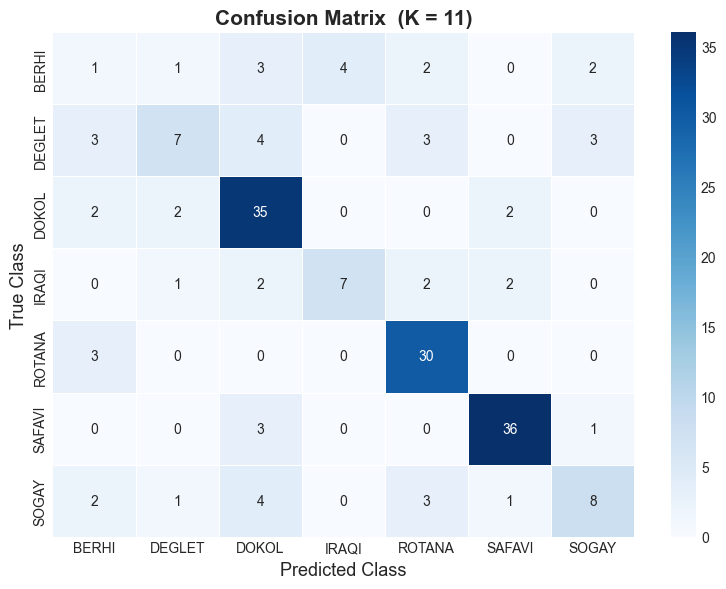

In [14]:
plt.figure(figsize=(8, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels,
            cbar=True, linewidths=0.5)

plt.xlabel('Predicted Class', fontsize=13)
plt.ylabel('True Class',      fontsize=13)
plt.title(f'Confusion Matrix  (K = {best_k})', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()